# imports

In [1]:
from pathlib import Path

import numpy as np
import polars as pl
from jaxtyping import Float
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# muutils
import muutils.tensor_info
from muutils.dbg import dbg_tensor

# attention-motifs
from attention_motifs.features.analysis import (
	null_stats,
	filter_data,
	normalize_data,
	pca_importance_table,
	aggregate_feature_stats,
	plot_importance_covariance,
)
from attention_motifs.features.plotting import (
	plot_embedding,
	apply_pca,
)

In [2]:
# magic autoreload
%load_ext autoreload
%autoreload 2

In [3]:
# numbers of rows to display
pl.Config.set_tbl_rows(10)
# colored muutils tensor info
muutils.tensor_info.DEFAULT_SETTINGS["colored"] = True
# base path
PATH_BASE: Path = Path("../data/features/")
PATH_FIGURES: Path = Path("figures/")

In [4]:
# raw data from file instead of regenerating
DATA_RAW = pl.read_ndjson(PATH_BASE / "raw-m8-p128-c101.jsonl")

# basic data inspection

In [5]:
# display(DATA_RAW)
# display(set(DATA_RAW.dtypes))
# display(DATA_RAW.head())
# display(DATA_RAW.describe())
# print(f"{DATA_RAW['activation.model'].unique() = }")
# for col in DATA_RAW.columns:
# 	if col.startswith("activation"):
# 		print(f"{col = }")
display(null_stats(DATA_RAW))

feature,missing_count,missing_frac
str,i64,f64
"""feat.diag.entropy""",0,0.0
"""feat.log.gram.skew.hist.median""",0,0.0
"""feat.log.gram.skew.hist.linreg…",0,0.0
"""activation.cache_key""",0,0.0
"""feat.diag.linreg.slope""",0,0.0
…,…,…
"""feat.log.gram.skew.hist.entrop…",0,0.0
"""feat.gram.row.hist.median""",0,0.0
"""feat.log.gram.skew.hist.rms""",0,0.0


# filter nans and certain models

In [6]:
# this will filter all-nan rows
DATA_FILTERED: pl.DataFrame = filter_data(
	DATA_RAW,
	# tinystories and small pythia models look very different in embedding space, so we get rid of them
	remove_models=["tiny-stories-1M", "pythia-14m"],
)
null_stats(DATA_FILTERED)

Removing 2 models: ['tiny-stories-1M', 'pythia-14m']
Removed 19456/214016 rows
Removing 2/94 feat.* columns due to zero variance or excessive missing values
feat.log.gram.row.hist.median                                μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=194560 dtype=float64
feat.log.gram.col.hist.median                                μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=194560 dtype=float64


feature,missing_count,missing_frac
str,i64,f64
"""feat.diag.entropy""",0,0.0
"""feat.log.gram.skew.hist.median""",0,0.0
"""feat.log.gram.skew.hist.linreg…",0,0.0
"""activation.cache_key""",0,0.0
"""feat.diag.linreg.slope""",0,0.0
…,…,…
"""feat.log.gram.skew.hist.entrop…",0,0.0
"""feat.gram.row.hist.median""",0,0.0
"""feat.log.gram.skew.hist.rms""",0,0.0


# scaling

In [7]:
FEATURE_COLS: list[str] = [
	col for col in DATA_FILTERED.columns if col.startswith("feat.")
]
DATA_SCALED: pl.DataFrame
_data_norms: pl.DataFrame
DATA_SCALED, _data_norms = normalize_data(DATA_FILTERED, FEATURE_COLS)
_data_norms.write_ndjson(PATH_BASE / "norms.jsonl")
DATA_SCALED.write_ndjson(PATH_BASE / "scaled.jsonl")
display(null_stats(DATA_SCALED))
META_COLS: list[str] = [
	col for col in DATA_SCALED.columns if col.startswith("activation.")
]

feature,missing_count,missing_frac
str,i64,f64
"""feat.diag.entropy""",0,0.0
"""feat.log.gram.skew.hist.median""",0,0.0
"""feat.log.gram.skew.hist.linreg…",0,0.0
"""activation.cache_key""",0,0.0
"""feat.diag.linreg.slope""",0,0.0
…,…,…
"""feat.log.gram.skew.hist.entrop…",0,0.0
"""feat.gram.row.hist.median""",0,0.0
"""feat.log.gram.skew.hist.rms""",0,0.0


In [8]:
# plot_correlation_matrix(
# 	DATA_SCALED,
# 	FEATURE_COLS,
# 	sort_by="var",
# )

# PCA

/home/miv/projects/attn/attention-motifs/attention_motifs/features/plotting.py:149: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


Number of components: 10
Total explained variance: 0.8581
Components needed for 80% variance: 7
Components needed for 90% variance: 1


[ <ipykernel>:6 ] PCA_DATA: μ=-0.00 σ=2.81 x̃=-0.14 R=[-13.83,28.78] ℙ=| ▂█    | shape=(194560,10) dtype=float64
[ <ipykernel>:7 ] PCA_OBJ.components_: μ=0.00 σ=0.10 x̃=-0.00 R=[-0.32,0.40] ℙ=| ▂▇█▂  | shape=(10,92) dtype=float64


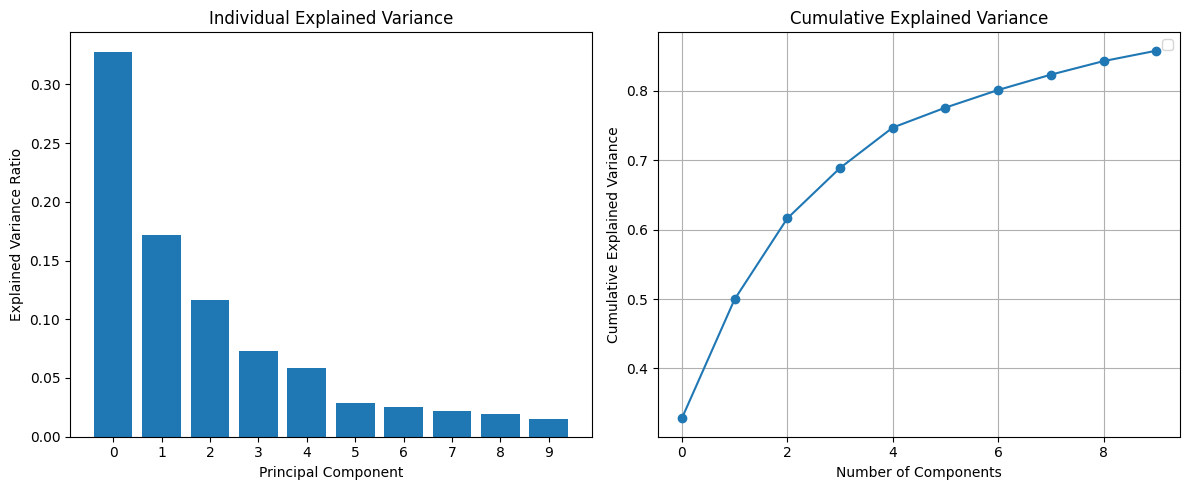

In [9]:
# dbg_tensor(DATA_SCALED[FEATURE_COLS].to_numpy())
PCA_DATA: np.ndarray
PCA_OBJ: PCA
PCA_DATA, PCA_OBJ = apply_pca(DATA_SCALED, n_components=10, feature_cols=FEATURE_COLS)
plt.savefig(PATH_FIGURES / "pca-variance.pdf", bbox_inches="tight", pad_inches=0.01)
dbg_tensor(PCA_DATA)
dbg_tensor(PCA_OBJ.components_)

# pca and meta in one dataframe
DF_PCA: pl.DataFrame = pl.concat(
	[
		# pca cols
		pl.DataFrame(PCA_DATA, schema=[f"pc.{i}" for i in range(PCA_DATA.shape[1])]),
		# metadata -- "activation.*"
		DATA_SCALED[META_COLS],
	],
	how="horizontal",
)
DF_PCA.write_ndjson(PATH_BASE / "pca.jsonl")

In [10]:
df_importance: pl.DataFrame = pca_importance_table(
	PCA_OBJ,
	feature_names=FEATURE_COLS,
)
df_importance.sort(pl.col("PC0").abs(), descending=True)

feature,PC0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,abs_mean,abs_max,abs_var,var_weighted
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""feat.log.gram.col.hist.linreg.…",0.175145,-0.028945,-0.010196,0.033493,-0.032688,-0.013156,0.032888,0.02886,0.034006,-0.016511,0.040589,0.175145,0.002085,0.070694
"""feat.log.gram.col.hist.linreg.…",-0.173638,0.037772,-0.011184,-0.033725,0.045994,0.001506,-0.05119,-0.033105,-0.011323,0.029667,0.04291,0.173638,0.002127,0.072598
"""feat.log.gram.col.hist.rms""",-0.171375,0.039043,0.039099,-0.015268,0.015728,0.003857,0.008708,-0.042172,-0.054364,0.021774,0.041139,0.171375,0.002128,0.072141
"""feat.log.gram.col.hist.linreg.…",0.170928,-0.04129,0.024326,0.031691,-0.05355,0.00693,0.058974,0.032195,0.00996,-0.033297,0.046314,0.170928,0.001971,0.074502
"""feat.log.gram.col.hist.varianc…",-0.170316,0.042038,0.042,-0.011483,0.0132,0.000083,0.014496,-0.045648,-0.056277,0.023803,0.041934,0.170316,0.002129,0.072407
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""feat.first_tok.entropy""",-0.004029,-0.158586,-0.013536,-0.05378,0.261133,0.056702,0.043948,-0.071943,0.00566,0.054096,0.072341,0.261133,0.005738,0.054495
"""feat.gram.row.hist.linreg.inte…",-0.002972,0.199096,-0.04057,0.024529,-0.154572,0.247228,-0.080188,-0.012783,-0.023325,-0.05814,0.08434,0.247228,0.006629,0.061429
"""feat.first_tok.kurtosis""",-0.00257,0.159032,-0.017511,-0.024788,-0.216914,-0.037234,0.029716,0.029418,0.117138,-0.108424,0.074275,0.216914,0.004672,0.051006


In [11]:
display(aggregate_feature_stats(df_importance, side=1).sort("max", descending=True))

token,mean,min,max,median
str,f64,f64,f64,f64
"""log""",0.065912,0.040589,0.127447,0.061847
"""diag""",0.098162,0.086339,0.122407,0.095952
"""first_tok""",0.085224,0.065009,0.117652,0.079818
"""gram""",0.079867,0.042467,0.11373,0.082139


/home/miv/projects/attn/attention-motifs/attention_motifs/features/analysis.py:419: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/miv/projects/attn/attention-motifs/attention_motifs/features/analysis.py:419: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


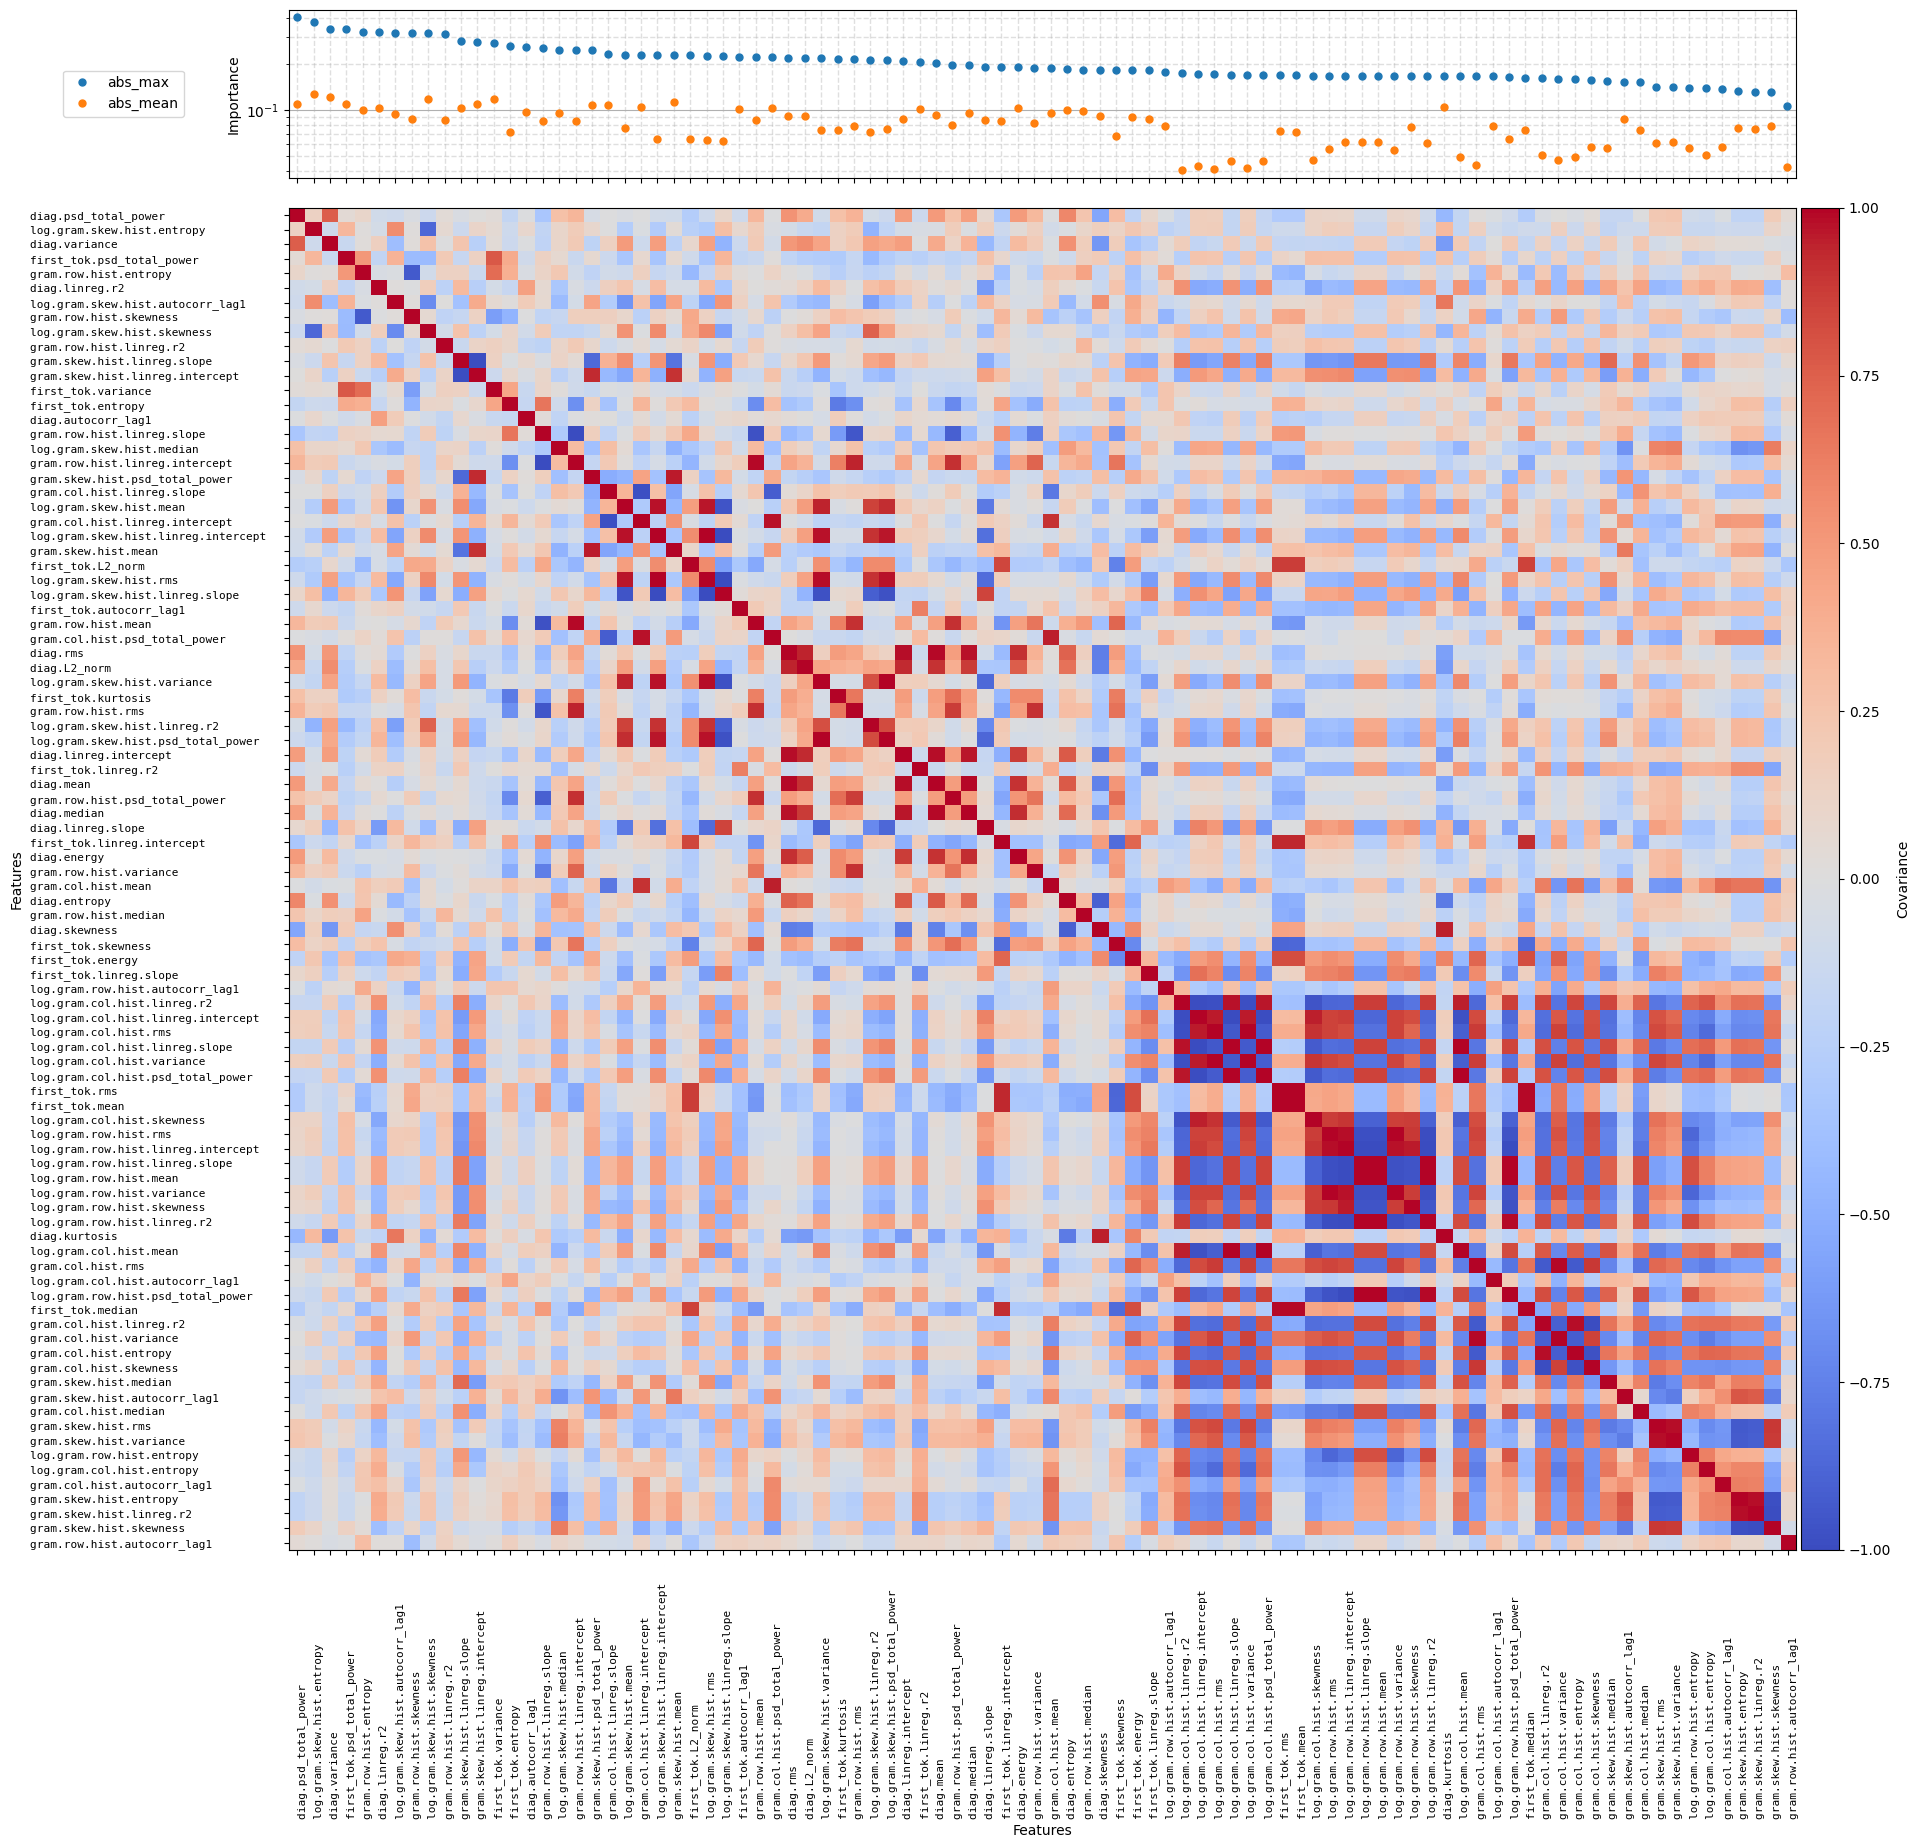

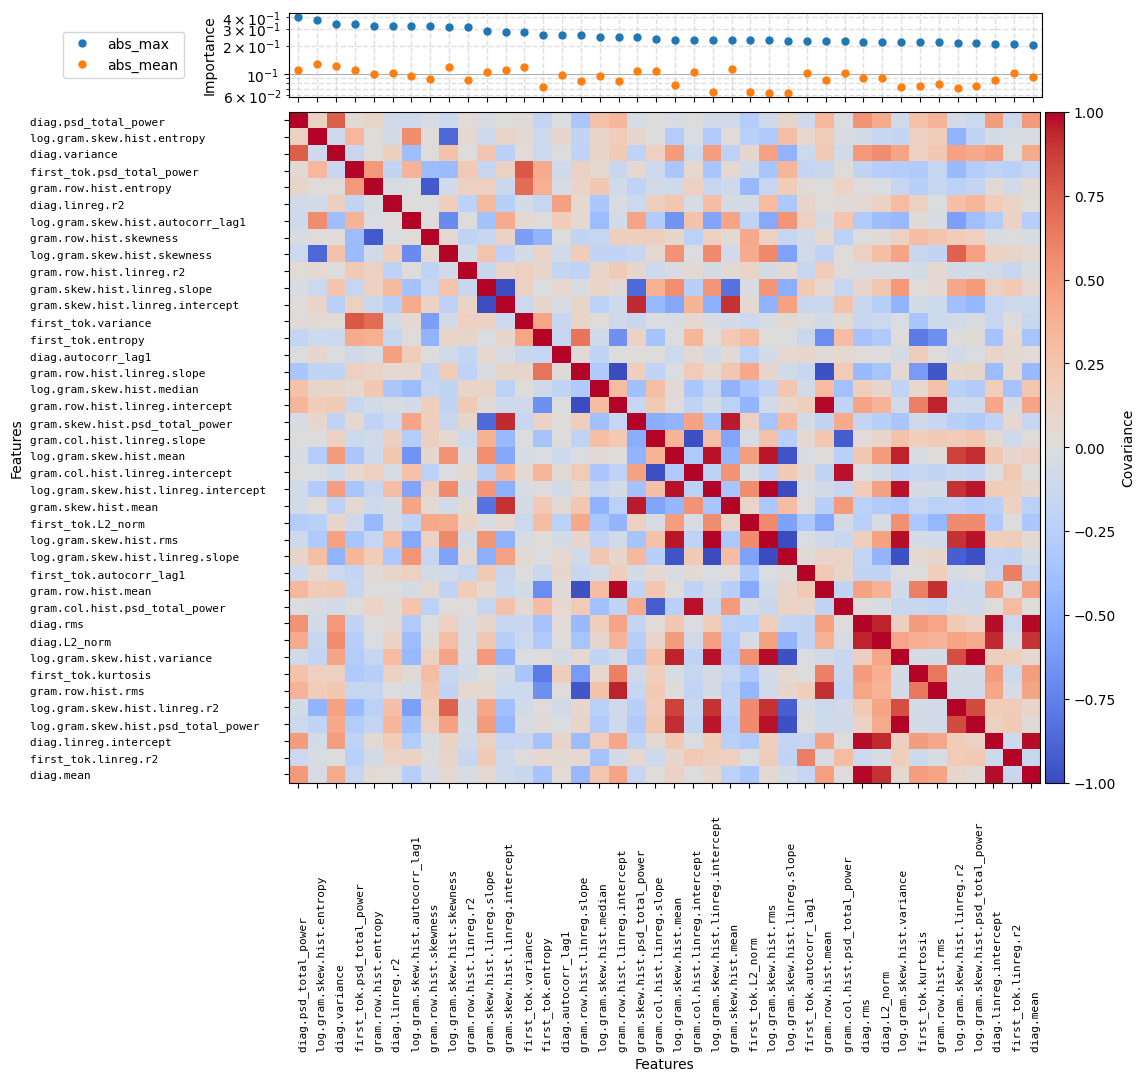

In [12]:
COV_FEATS: list[str]
COV_MAT: Float[np.ndarray, "n_features n_features"]

# full
COV_FEATS, COV_MAT = plot_importance_covariance(
	DATA_SCALED,
	df_importance,
	# feature_order=sorted(FEATURE_COLS, key=lambda x: x.split(".")[-1]),
	metrics=["abs_max", "abs_mean"],
	descending=True,
	cmap="coolwarm",
	figsize=(20, 20),
	tick_pad=100,
	imp_legend_align=-0.15,
)
plt.savefig(PATH_FIGURES / "feature-cov-full.pdf", bbox_inches="tight", pad_inches=0.01)

# reduced
plot_importance_covariance(
	DATA_SCALED,
	df_importance,
	# feature_order=sorted(FEATURE_COLS, key=lambda x: x.split(".")[-1]),
	metrics=["abs_max", "abs_mean"],
	descending=True,
	cmap="coolwarm",
	figsize=(10, 10),
	tick_pad=100,
	importance_threshold=0.2,
)
plt.savefig(PATH_FIGURES / "feature-cov-reduced.pdf", bbox_inches="tight", pad_inches=0.01)

In [13]:
# from attention_motifs.features.analysis import print_covariance_groups
# print_covariance_groups(
# 	cov_feats=COV_FEATS,
# 	cov_mat=COV_MAT,
# 	df_importance=df_importance,
# 	threshold=0.9,
# )

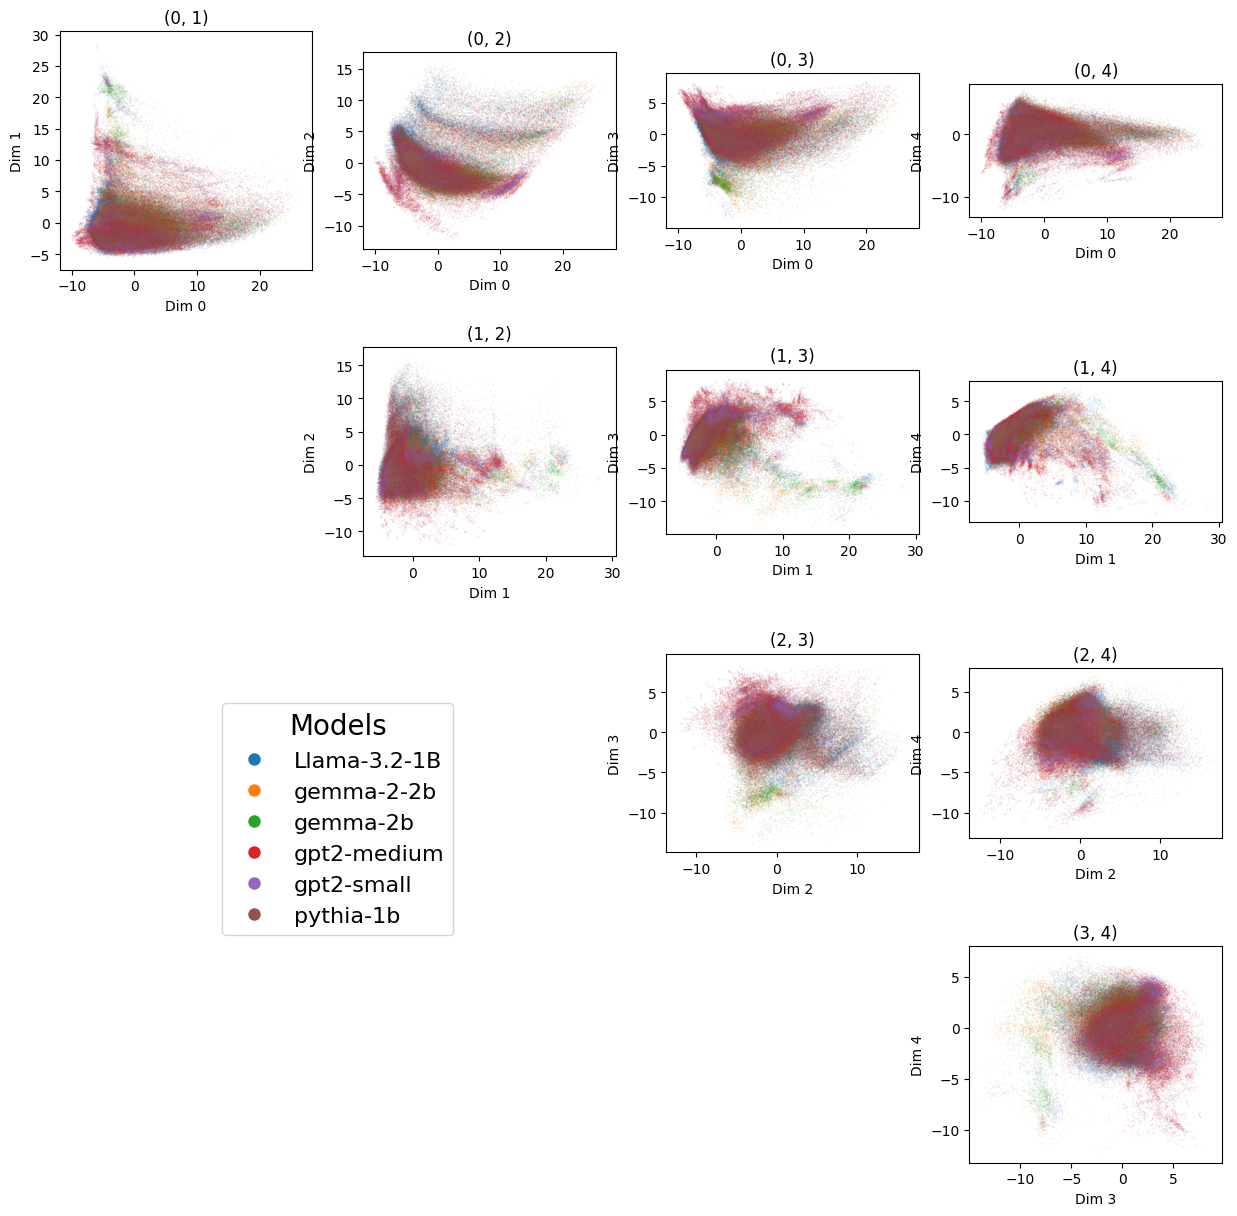

In [23]:
n_dims: int = 5
embed_fig, embed_ax = plt.subplots(
	n_dims - 1,
	n_dims - 1,
	figsize=(15, 15),
)
for i in range(0, n_dims - 1):
	for j in range(i + 1, n_dims):
		handles = plot_embedding(
			PCA_DATA,
			DATA_SCALED["activation.model"],
			(i, j),
			alpha=0.1,
			marker_size=1,
			title=f"({i}, {j})",
			ax=embed_ax[i, j - 1],
			do_legend=False,
		)
	for k in range(0, i):
		embed_ax[i, k].axis("off")
plt.legend(
	handles=handles,
	loc="lower left",
	bbox_to_anchor=(-3, 1),
	title="Models",
	fontsize=16,
	title_fontsize=20,
)
plt.savefig(PATH_FIGURES / "pca-all.png", dpi=500, bbox_inches="tight", pad_inches=0.01)

In [15]:
DATA_SCALED

feat.diag.entropy,feat.log.gram.skew.hist.median,feat.log.gram.skew.hist.linreg.intercept,activation.cache_key,feat.diag.linreg.slope,feat.gram.skew.hist.variance,feat.log.gram.col.hist.skewness,feat.log.gram.skew.hist.mean,feat.gram.row.hist.linreg.intercept,feat.gram.col.hist.variance,activation.head,activation.n_ctx,feat.gram.skew.hist.entropy,feat.gram.skew.hist.linreg.intercept,feat.gram.col.hist.mean,feat.diag.mean,feat.gram.skew.hist.linreg.r2,feat.gram.col.hist.skewness,feat.diag.kurtosis,feat.gram.skew.hist.psd_total_power,feat.gram.row.hist.mean,feat.gram.col.hist.linreg.r2,feat.gram.skew.hist.median,feat.gram.col.hist.linreg.slope,feat.diag.skewness,feat.first_tok.entropy,feat.gram.row.hist.linreg.slope,feat.log.gram.row.hist.skewness,feat.log.gram.col.hist.autocorr_lag1,feat.gram.col.hist.rms,feat.log.gram.skew.hist.linreg.r2,feat.first_tok.psd_total_power,feat.gram.row.hist.psd_total_power,feat.gram.col.hist.linreg.intercept,feat.log.gram.col.hist.psd_total_power,activation.layer,feat.gram.skew.hist.linreg.slope,…,feat.diag.linreg.r2,feat.log.gram.row.hist.linreg.slope,feat.log.gram.col.hist.linreg.intercept,feat.first_tok.median,feat.diag.autocorr_lag1,feat.first_tok.kurtosis,feat.gram.skew.hist.skewness,feat.diag.psd_total_power,feat.diag.energy,activation.cls,feat.log.gram.col.hist.linreg.slope,feat.first_tok.linreg.intercept,feat.first_tok.linreg.slope,feat.log.gram.row.hist.linreg.intercept,feat.first_tok.energy,feat.log.gram.col.hist.mean,feat.log.gram.row.hist.autocorr_lag1,feat.first_tok.variance,feat.gram.skew.hist.autocorr_lag1,feat.log.gram.col.hist.rms,feat.log.gram.skew.hist.variance,feat.log.gram.skew.hist.autocorr_lag1,feat.log.gram.col.hist.variance,feat.diag.rms,feat.diag.linreg.intercept,feat.first_tok.L2_norm,feat.gram.row.hist.skewness,feat.gram.row.hist.rms,feat.gram.skew.hist.rms,activation.model,feat.gram.col.hist.median,feat.log.gram.row.hist.entropy,feat.log.gram.skew.hist.entropy,feat.gram.row.hist.median,feat.log.gram.skew.hist.rms,feat.log.gram.skew.hist.psd_total_power,feat.log.gram.skew.hist.linreg.slope
f64,f64,f64,str,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64
0.924762,1.680169,-0.202521,"""blocks.0.attn.hook_pattern""",0.551493,0.9532,0.632443,-0.043862,-0.148865,0.749446,0,109,-1.104428,-0.27878,-0.63981,0.188895,-1.078767,0.735821,-1.347009,-0.527169,-0.131938,-0.743633,-0.478502,0.204488,-1.25653,0.595424,0.155049,0.45062,-1.545033,0.754217,0.111103,0.745983,-0.284212,-0.365125,-0.730617,0,0.091779,…,-1.059392,-0.684034,0.763975,0.271778,-0.52873,-0.355537,1.106297,1.804951,0.090481,"""gemma-2b:L0:H0""",-0.766695,0.030602,0.215031,0.684222,-0.004741,-0.760119,-1.950965,1.049703,-0.724955,0.917424,-0.336878,4.781122,0.932892,0.458822,0.017129,-0.06103,-1.349667,-0.218839,0.95897,"""gemma-2b""",-0.504639,-0.622777,-0.278865,0.853787,-0.314558,-0.417044,0.255678
-0.418394,0.542598,-0.273348,"""blocks.0.attn.hook_pattern""",0.452354,1.822832,0.639197,-0.193015,0.610442,1.335746,1,109,-1.431659,-0.481843,-1.194979,-0.421555,-1.31253,0.820295,0.476347,-0.718787,0.661144,-0.953984,-1.00518,0.639536,0.544125,0.683147,-0.583193,0.45062,0.433484,1.214414,-0.105551,2.473359,-0.165753,-0.863056,-0.896396,0,0.215211,…,-0.673847,-0.684034,0.932186,-0.007139,-0.439228,-0.441883,1.224311,-0.283993,-0.236822,"""gemma-2b:L0:H1""",-0.946679,-0.60339,0.930868,0.684222,0.003357,-0.948187,-1.950965,3.126453,-1.136711,0.993409,-0.333598,-0.648657,1.017918,-0.423572,-0.536375,-0.054721,-0.342122,0.267115,1.616427,"""gemma-2b""",-0.756184,-0.622777,-0.278865,1.313925,-0.316685,-0.485568,0.298282
0.440586,-0.045614,-0.331099,"""blocks.0.attn.hook_pattern""",0.333615,-0.339769,0.610897,-0.455545,-0.313954,0.062157,2,109,0.287511,1.060029,1.051573,0.015846,0.284887,0.0677